# Accesibilidad de segundo orden

Este *notebook* contiene un primer acercamiento al concepto de "accesibilidad
de segundo orden", que involucra medir la accesibilidad a servicios no
solamente considerando lugares de vivienda, sino que también lugares de trabajo
y/o estudio. Considerando un modelo de accesibilidad que incluya oferta y
  demanda, se desea ver cómo cambia la accesibilidad si se considera no
  solamente la población que vive en cada zona, sino que también la población
  que trabaja en la misma.

Se utilizará el Gran Santiago como área de estudio, considerando 4 tipos de
servicios que son comunes de acceder tanto si uno vive en el lugar como si uno
trabaja en el mismo:

- Farmacias.
- Supermercados o tiendas de conveniencia.
- Bancos.
- Centros de salud (privados o CESFAM).

**IMPORTANTE**: para ejecutar este *notebook*, se requiere la ubicación (en
coordenadas) de empleos formales en Chile. Los datos utilizados (provenientes
del SII) utilizan direcciones en texto, por lo que se requiere un proceso de
*geocoding* que no se realiza por defecto al ejecutar
[`make_dataset.py`](../../scripts/make_dataset.py).

Para poder realizar este *geocoding*, se debe habilitar una base de datos local
de Nominatim, cargada con el archivo PBF `Chile.osm.pbf` (que cubre todo el
país). Instrucciones sobre cómo instalar Nominatim se encuentran
[aquí](https://nominatim.org/release-docs/latest/admin/Installation/), mientras
que las instrucciones para importar datos desde un archivo PBF se encuentran
[aquí](https://nominatim.org/release-docs/latest/admin/Import/).

Una vez habilitada la base de datos, se debe agregar la ruta a la instalación
de la base de datos a un archivo `.env` bajo el nombre `NOMINATIM_PATH` (es
decir, el archivo .env debe tener una línea que dice `NOMINATIM_PATH=<ruta a la
instalación>`). Finalmente, se puede ejecutar el comando `uv sync --extra
nominatim` para instalar los paquetes necesarios para llamar a la base de datos
creada, y luego ejecutar `uv run scripts/make_dataset.py trabajos` para
realizar la descarga y procesamiento de los datos.

In [1]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import datetime
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

from libpysal import weights
import mapclassify
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

import xmin
from xmin.dataset import extract_osm_subset
from xmin.indices import EnhancedTwoStepFca

tqdm.pandas()

In [3]:
RAW_DATA_PATH = Path("../../data/raw")  # datos no procesados
PRE_DATA_PATH = Path("../../data/processed")  # datos preprocesados
IMG_PATH = Path("../../reports/figures")
xmin.config.quackosm_working_directory = Path("../../data/interim/quackosm")

In [4]:
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"

CENSO_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
AMENITY_SALUD_PATH = PRE_DATA_PATH / "amenities" / "salud.gpkg"
TRABAJOS_PATH = PRE_DATA_PATH / "trabajos" / "trabajos.gpkg"
OSM_SANTIAGO_PATH = PRE_DATA_PATH / "osm" / "Santiago.osm.pbf"

## Orígenes, destinos y TTMs

In [5]:
# carga de datos
limites_urbanos_full = gpd.read_file(
    CENSO_PATH,
    layer="Limite_Urbano_CPV24",
)

# filtramos solo las áreas de interés
limites_urbanos = limites_urbanos_full[
    (limites_urbanos_full["LOCALIDAD"] == "GRAN SANTIAGO")
]

# obtenemos envoltura convexa para extraer POIs y red vial
limites_envoltura = limites_urbanos.union_all().convex_hull

In [6]:
manzanas = gpd.read_file(
    CENSO_PATH,
    layer="Manzanas_CPV24",
    mask=limites_urbanos.union_all(),
    use_arrow=True
)

En primera instancia, creamos el objeto `Origins` considerando que no hay
población trabajadora; luego agregaremos la misma y compararemos el efecto que
tiene.

In [7]:
origins = xmin.Origins.create_grid(
    regions=limites_urbanos,
    h3_resolution=9,
    population_gdf=manzanas.rename(columns={"n_per": "population"}),
)

In [8]:
if not OSM_SANTIAGO_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_SANTIAGO_PATH,
        bounds=limites_envoltura
    )

In [9]:
farmacias = xmin.Amenity.from_osm(
    name="farmacias",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"amenity": ["pharmacy"]},
    keep_all_tags=["name"]
)

In [10]:
supermercados = xmin.Amenity.from_osm(
    name="supermercados",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"shop": ["supermarket", "convenience"]},
    keep_all_tags=["name"]
)

In [11]:
bancos = xmin.Amenity.from_osm(
    name="bancos",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"amenity": "bank"},
    keep_all_tags=["name"]
)

In [12]:
salud_gdf = gpd.read_file(AMENITY_SALUD_PATH, mask=limites_envoltura)

salud = xmin.Amenity(
    name="salud",
    amenity_gdf=salud_gdf[salud_gdf["TIPO"].isin(
        ["Centro de Salud Privado", "Centro de Salud Familiar (CESFAM)"]
    )]
)

In [13]:
ttms = xmin.TravelTimeMatrices.compute(
    origins=origins,
    amenities=[farmacias, supermercados, bancos, salud],
    gtfs_paths=[],
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=30),
    transport_modes=["WALK"],
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

In [14]:
trabajos = gpd.read_file(TRABAJOS_PATH)

## Cálculo de poblaciones

La población trabajadora no necesariamente tiene la misma demanda que quienes
viven en el lugar; por ende, a la población que vive le sumaremos la población
trabajadora ponderada por un parámetro $\alpha$, entre 0 y 1. Si vale 0,
entonces la población trabajadora no tiene impacto. Si vale 1, entonces la
población trabajadora demanda los servicios en igual medida que quienes viven
ahí, y valores intermedios exhiben comportamientos intermedios.

In [15]:
population_grid = origins.h3_grid.set_index("id").rename(
    columns={"population": "pop_vivienda"}
)

population_grid["pop_trabajo"] = trabajos.sjoin(
    population_grid, how="inner", predicate="within"
).groupby("id_right")["weight"].sum()
population_grid["pop_trabajo"] = population_grid["pop_trabajo"].fillna(0)

# reset index and reorder columns
population_grid = population_grid[
    ["pop_vivienda", "pop_trabajo", "geometry"]
].reset_index()

In [16]:
origins_work_25 = xmin.Origins(
    origins.regions,
    origins.h3_resolution,
    population_grid.assign(
        population=(
            population_grid["pop_vivienda"]
            + 0.25 * population_grid["pop_trabajo"]
        )
    )
)

origins_work_50 = xmin.Origins(
    origins.regions,
    origins.h3_resolution,
    population_grid.assign(
        population=(
            population_grid["pop_vivienda"]
            + 0.50 * population_grid["pop_trabajo"]
        )
    )
)

origins_work_100 = xmin.Origins(
    origins.regions,
    origins.h3_resolution,
    population_grid.assign(
        population=(
            population_grid["pop_vivienda"]
            + population_grid["pop_trabajo"]
        )
    )
)

In [17]:
ttms_work_25 = xmin.TravelTimeMatrices(
    origins_work_25,
    ttms.amenities.values(),
    ttms.matrices
)

ttms_work_50 = xmin.TravelTimeMatrices(
    origins_work_50,
    ttms.amenities.values(),
    ttms.matrices
)

ttms_work_100 = xmin.TravelTimeMatrices(
    origins_work_100,
    ttms.amenities.values(),
    ttms.matrices
)

## Cálculo de accesibilidad

Calculamos la accesibilidad usando E2SFCA, considerando así oferta y demanda.
Se asignaron pesos acorde a la frecuencia con la cual se utiliza cada servicio.

In [ ]:
index = EnhancedTwoStepFca(
    catchment_areas=[
        (0, 10, 1.00),
        (10, 20, 0.42),
        (20, 30, 0.03),
    ],
    desired_ratio=3_000,
)

acc_weights = {
    "farmacias": 1,
    "supermercados": 1,
    "bancos": 0.5,
    "salud": 0.5,
}

In [19]:
acc_work_0 = xmin.AccessibilityRatings.compute(ttms, index, acc_weights)
acc_work_25 = xmin.AccessibilityRatings.compute(ttms_work_25, index, acc_weights)
acc_work_50 = xmin.AccessibilityRatings.compute(ttms_work_50, index, acc_weights)
acc_work_100 = xmin.AccessibilityRatings.compute(ttms_work_100, index, acc_weights)

Calculando índices para cada necesidad...


  0%|          | 0/4 [00:00<?, ?it/s]

Calculando índices para cada necesidad...


  0%|          | 0/4 [00:00<?, ?it/s]

Calculando índices para cada necesidad...


  0%|          | 0/4 [00:00<?, ?it/s]

Calculando índices para cada necesidad...


  0%|          | 0/4 [00:00<?, ?it/s]

## Visualizaciones

### Comparación entre ponderaciones

Observando cómo cambia la accesibilidad a medida que aumenta el peso que se le
entrega a la población trabajadora, se aprecia que todas las zonas de Santiago
sufren una disminución en sus puntuaciones; esto tiene sentido, pues aumenta la
demanda mientras la oferta se mantiene igual. Sin embargo, es interesante notar
cuáles zonas son las que disminuyen en mayor medida.

Visualizando la diferencia entre la accesibilidad con $\alpha=0$ y la
accesibilidad con $\alpha=0.5$, notamos que las zonas con mayor disminución son
Ciudad Empresarial (Huechuraba), el barrio industrial en Quilicura Norte, el
eje Santa María-Presidente Kennedy (Providencia/Las Condes/Vitacura), el eje
Eliodoro Yáñez-Cristóbal Colón (Providencia/Las Condes) y la zona industrial en
la intersección entre Maipú, San Bernardo y Cerrillos. Estos son lugares que
tienen servicios suficientes para las personas que viven en el lugar (que
tienden a ser pocas), pero no para quienes trabajan ahí. Se puede contrastar la
disminución de la accesibilidad en estas áreas con otras como el centro de
Santiago o el eje Providencia, que tienen una mayor robustez de servicios capaz
de cubrir no solamente a quienes viven en el lugar, sino que también a su
población "flotante" que viaja por motivos de empleo. De esta forma, sus
puntuaciones de accesibilidad no se ven reducidas particularmente al incluir a
la población trabajadora.

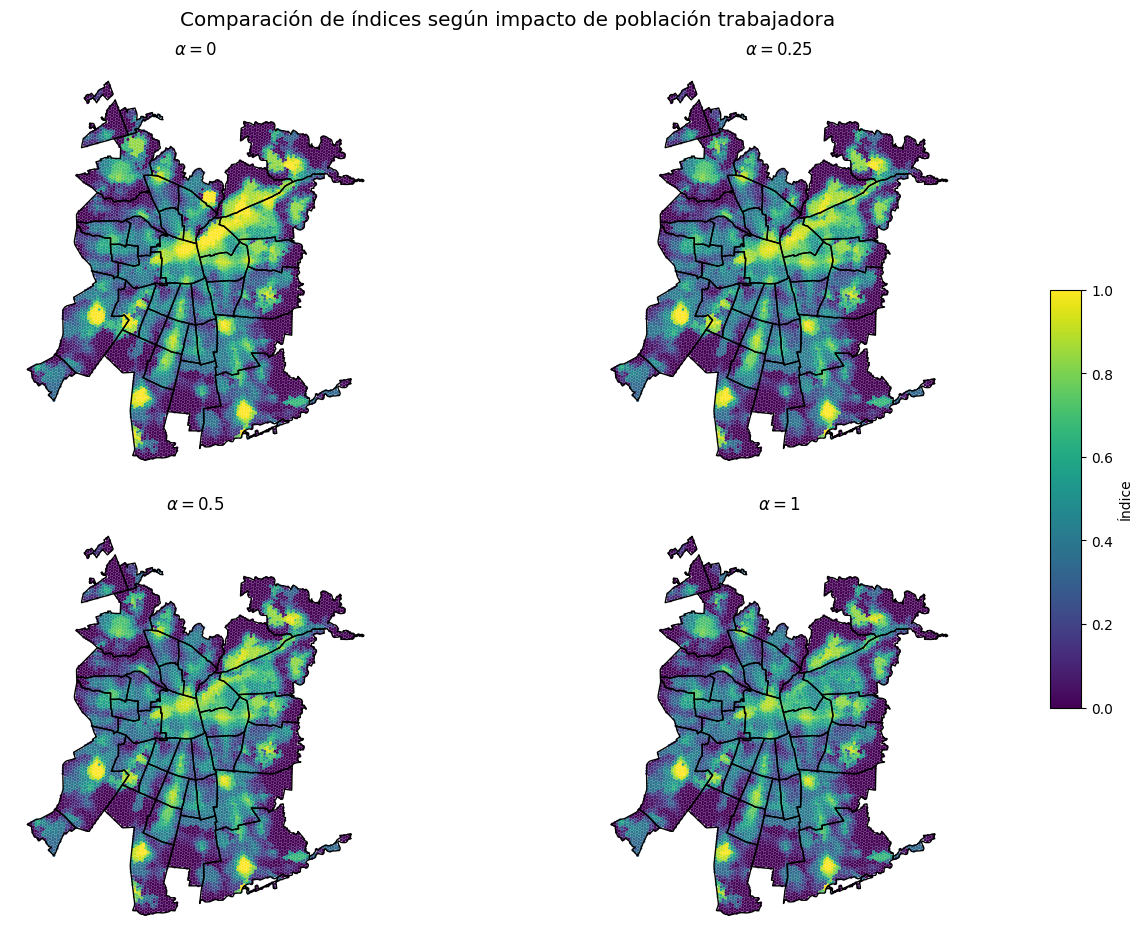

In [ ]:
fig = plt.figure(figsize=(2 * 6.4, 2 * 4.8))
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_normal = fig.add_subplot(gs[0:2, 0])
ax_smooth = fig.add_subplot(gs[0:2, 1])
ax_50 = fig.add_subplot(gs[2:4, 0])
ax_100 = fig.add_subplot(gs[2:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

for ax, acc, name in zip(
    (ax_normal, ax_smooth, ax_50, ax_100),
    (acc_work_0, acc_work_25, acc_work_50, acc_work_100),
    (r"$\alpha=0$", r"$\alpha=0.25$", r"$\alpha=0.5$", r"$\alpha=1$")
):
    acc.visualize.choropleth("total", ax=ax)
    ax.set_axis_off()
    ax.set_title(name)

cbar = plt.cm.ScalarMappable(cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Índice")

fig.suptitle(
    "Comparación de índices según impacto de población trabajadora",
    fontsize="x-large"
)

plt.tight_layout()
plt.savefig(IMG_PATH / "impacto_trabajo.pdf")

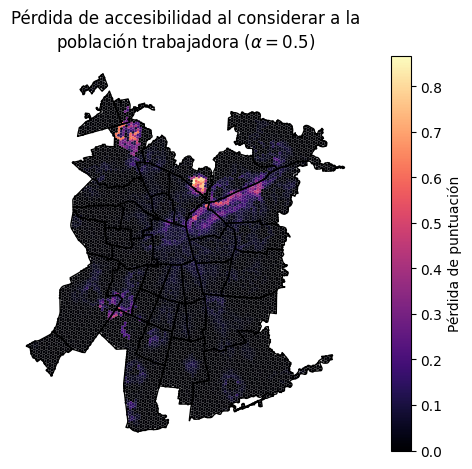

In [54]:
ax = acc_work_50.visualize.choropleth(
    acc_work_0.gdf["total"] - acc_work_50.gdf["total"],
    legend=True,
    legend_kwds={"label": "Pérdida de puntuación"},
    cmap="magma"
)
ax.set_axis_off()
ax.set_title(
    "Pérdida de accesibilidad al considerar a la\n"
    "población trabajadora ($\\alpha=0.5$)")

plt.tight_layout()
plt.savefig(IMG_PATH / "impacto_trabajo_diff.pdf")

### Relación entre accesibilidad y población trabajadora

La siguiente visualización muestra la relación entre la accesibilidad calculada
considerando población trabajadora ($\alpha=0.5$) y la población trabajadora
en cada celda, mediante un mapa de coropletas bivariadas.

En primera instancia, se suavizó la población trabajadora (usando una función
de kernel) para reducir el ruido en la visualización, y entendiendo que, más
que la población en cada punto específico, nos interesan la cantidad aproximada
de trabajadores que pueden buscar acceder a servicios en el lugar. Esto implica
que no solo nos interesa la población del punto como tal, sino que también la
población de sectores aledaños.

Analizando la relación según el mapa de coropletas bivariadas, y
concentrándonos en los lugares con mayor población trabajadora, se observa una
clara diferencia entre aquellos lugares que pueden ser considerados "centros" y
los que son simplemente polos de trabajo. Los "centros" no solamente concentran
una alta cantidad de trabajadores, sino que también una alta cantidad de
servicios, capaces de satisfacer tanto a la población permanente como a la
población flotante. En el Gran Santiago, cumplen estas condiciones los puntos
coloreados de azul más oscuro, concentrándose en el centro histórico de
Santiago, el eje Providencia y parte del eje Apoquindo en Las Condes. Estos son
lugares a los que la gente acude por trabajo, pero donde también pueden acceder
a servicios y realizar distintos trámites.

Por otra parte, los polos de trabajo atraen una gran cantidad de trabajadores,
pero no poseen los servicios para satisfacer a la población (permanente y
trabajadora). En el Gran Santiago, cumplen estas condiciones los puntos
coloreados de celeste/azul claro, siendo el más notorio Ciudad Empresarial en
Quilicura. También destaca el eje Presidente Kennedy entre Las Condes y
Vitacura, y en menor medida (ya que poseen menos trabajadores) barrios
industriales en distintas comunas periféricas de la ciudad. Estos lugares
atraen a muchas personas por motivos de trabajo, pero para convertirse en
"centros" necesitan además ofrecer servicios para quienes viven y trabajan ahí.

In [35]:
# pesos para computar suavizado (kernel)
w = weights.Kernel.from_dataframe(population_grid, diagonal=True)
w.transform = "r"

# población trabajadora suavizada
population_grid["smooth_trabajo"] = weights.spatial_lag.lag_spatial(
    w, population_grid['pop_trabajo']
)

/home/clau/x-minute-chile/.venv/lib/python3.12/site-packages/libpysal/weights/distance.py:569: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, weights, ids, **kwargs)


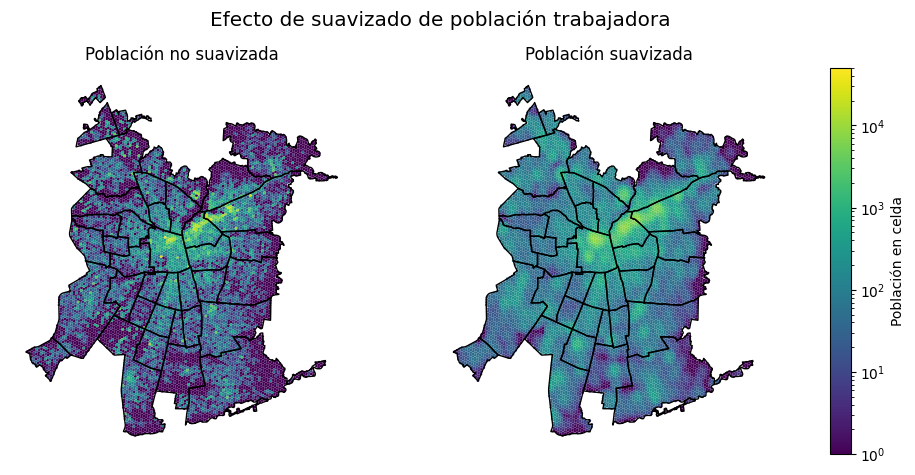

In [46]:
fig = plt.figure(figsize=(1.5 * 6.4, 4.8))
gs = GridSpec(1, 3, figure=fig, width_ratios=[100, 100, 5])
ax_normal = fig.add_subplot(gs[0, 0])
ax_smooth = fig.add_subplot(gs[0, 1])
ax_cb = fig.add_subplot(gs[0, 2])

norm = mcolors.LogNorm(vmin=1, vmax=50_000, clip=True)

for ax, column, name in zip(
    (ax_normal, ax_smooth),
    ("pop_trabajo", "smooth_trabajo"),
    ("Población no suavizada", "Población suavizada")
):
    population_grid.plot(column, norm=norm, ax=ax)
    origins.regions.plot(facecolor="none", edgecolor="black", ax=ax)
    ax.set_axis_off()
    ax.set_title(name)

cbar = plt.cm.ScalarMappable(norm=norm, cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Población en celda")

fig.suptitle(
    "Efecto de suavizado de población trabajadora",
    fontsize="x-large"
)

plt.tight_layout()
plt.savefig(IMG_PATH / "impacto_trabajo_smoothing.pdf")

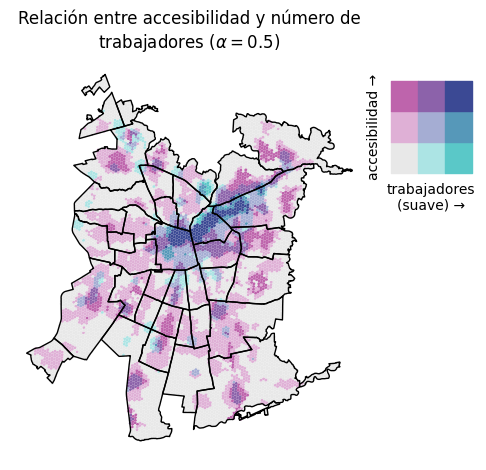

In [53]:
ax = acc_work_50.visualize.bivariate_choropleth(
    acc_work_50.gdf["total"].rename("accesibilidad"),
    population_grid.set_index("id")["smooth_trabajo"].rename(
        "trabajadores\n(suave)"
    ),
    classifier=(
        mapclassify.EqualInterval,
        lambda y, _: mapclassify.UserDefined(y, [225, 1000, 100_000])
    ),
    legend=True,
)

ax.set_axis_off()
ax.set_title(
    "Relación entre accesibilidad y número de\ntrabajadores ($\\alpha=0.5$)"
)

plt.tight_layout()
plt.savefig(IMG_PATH / "impacto_trabajo_bivariate.pdf")